Úloha 3: Vlastní model (Zombie apokalypsa)

Vlastní téma zpracované metodou soustavy obyčejných diferenciálních rovnic (SZR model).
    Model vychází z upravené struktury SIR modelu, kterou jsme řešili v Úloze 2 . Populaci rozdělíme do tří kategorií:

        S (Susceptible): Zdraví lidé, kteří mohou být nakaženi.
        Z (Zombies): Nakažení jedinci, kteří aktivně loví lidi.
        R (Removed): "Zneškodnění" zombie, kteří jsou však v tomto modelu schopni reanimace (oživení).

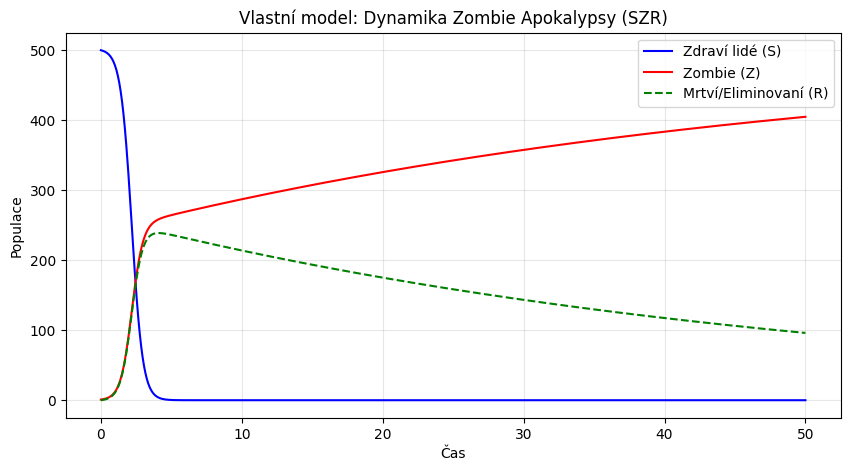

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Definice vlastního modelu (Zombie apokalypsa SZR)
def zombie_model(y, t, alpha, beta, zeta):
    S, Z, R = y
    
    # 1. Zdraví lidé ubývají nákazou
    dSdt = -alpha * S * Z           
    
    # 2. Zombie přibývají nákazou a ožitím mrtvých, ubývají bojem
    # TADY BYLA CHYBA: přejmenováno z dIdt na dZdt
    dZdt = alpha * S * Z + zeta * R - beta * S * Z  
    
    # 3. Mrtví (eliminovaní) přibývají bojem a ubývají opětovným ožitím
    dRdt = beta * S * Z - zeta * R  
    
    return [dSdt, dZdt, dRdt]

# Parametry a počáteční podmínky
t = np.linspace(0, 50, 1000)
y0 = [500, 1, 0] # 500 lidí, 1 první zombie, 0 mrtvých
alpha, beta, zeta = 0.01, 0.005, 0.02 

# Výpočet
sol = odeint(zombie_model, y0, t, args=(alpha, beta, zeta))

# Vykreslení
plt.figure(figsize=(10, 5))
plt.plot(t, sol[:, 0], 'b', label='Zdraví lidé (S)')
plt.plot(t, sol[:, 1], 'r', label='Zombie (Z)')
plt.plot(t, sol[:, 2], 'g--', label='Mrtví/Eliminovaní (R)')

plt.title("Vlastní model: Dynamika Zombie Apokalypsy (SZR)")
plt.xlabel("Čas")
plt.ylabel("Populace")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Vysvětlení modelu. 


Model je implementován jako soustava tří nelineárních diferenciálních rovnic. Proměnné reprezentují tři stavy populace: zdravé (S), nakažené/zombie (Z) a dočasně eliminované (R). Klíčovým prvkem je koeficient zeta, který určuje rychlost reanimace mrtvých zpět do stavu zombie.